# 04. Modeling
The goal of this notebook is to train and compare supervised models that estimate customer churn probability.

This stage focuses on selecting an appropriate modeling approach for risk ranking, rather than producing a final decision rule. Multiple model classes are evaluated to assess how well they combine weak individual signals into a meaningful churn risk score.

The output of this stage is a candidate predictive model (or small set of models) to be used in the subsequent evaluation of retention strategies.

## 4.1. Modeling Framing

Task: binary classification with probabilistic output.

Model output: churn probability, used for customer risk ranking and downstream threshold-based actions.

Multiple model classes are evaluated (baseline, interpretable, flexible) to assess trade-offs between ranking performance, stability, and interpretability.

## 4.2. Load artifacts from Data Preparation

In [30]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss )

In [31]:
м=X_train = pd.read_csv("../data/X_train.csv")
X_test  = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv")["churn"]
y_test  = pd.read_csv("../data/y_test.csv")["churn"]

### 4.2.1. Sanity checks + minimal cleaning for baseline

In [32]:
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(4800, 17) (1200, 17)
0.33791666666666664 0.3383333333333333


In [33]:
assert list(X_train.columns) == list(X_test.columns), "Train/test feature columns mismatch."
assert y_train.isin([0, 1]).all() and y_test.isin([0, 1]).all(), "y must be binary (0/1)."

### 4.2.2. Convert common boolean string values to 0/1 (if present)

In [34]:
obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
if obj_cols:
    for c in obj_cols:
        X_train[c] = X_train[c].replace({"True": 1, "False": 0, "true": 1, "false": 0})
        X_test[c]  = X_test[c].replace({"True": 1, "False": 0, "true": 1, "false": 0})

### 4.2.3. Re-check object columns; if any remain, they are likely categorical -> baseline needs encoding

In [35]:
obj_cols_after = X_train.select_dtypes(include=["object"]).columns.tolist()

if obj_cols_after:
    print("Categorical columns detected:", obj_cols_after)

Categorical columns detected: ['plan', 'region', 'industry']


## 4.3 Baseline Model
Establish a simple probabilistic baseline for churn risk ranking. Logistic Regression with standardized features is used as a reference model for subsequent comparisons.

### 4.3.1. Identify numeric and categorical features to define appropriate preprocessing strategies

In [37]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("categorical:", cat_cols)
print("numeric:", num_cols)

categorical: ['plan', 'region', 'industry']
numeric: ['customer_id', 'tenure_months', 'team_size', 'monthly_price', 'logins_per_week', 'campaigns_per_month', 'automation_used', 'onboarding_completed', 'integrations_connected', 'support_tickets_90d', 'avg_response_hours', 'nps', 'failed_payments_6m', 'discount_used']


### 4.3.2. Missing value handling

In [38]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

### 4.3.3. Standardize numeric features and one-hot encode categorical features using a unified preprocessing pipeline

In [39]:
preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ]
)

### 4.3.4. Define a Logistic Regression model with default hyperparameters as a simple probabilistic baseline

In [40]:
baseline_lr = Pipeline([
    ("preprocess", preprocess_lr),
    ("model", LogisticRegression(max_iter=2000))
])

### 4.3.5. Fit the preprocessing pipeline and baseline model on the training data

In [41]:
baseline_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['customer_id',
                                                   'tenure_months', 'team_size',
                                                   'monthly_price',
                                                   'logins_per_week',
                                                   'campaigns_per_month',
                                                   'automation_used',
                                                   'onboarding_completed',
                                                   'integrations_connected',
                                                   'support_tickets_90d',
                                                   'avg_response_hours', 'nps',
                                                   'failed_payments_6m',
                                                   'discount_used']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['plan', 'region',
                                                   'industry'])])),
                ('model', LogisticRegression(max_iter=2000))])

### 4.3.6. Generate churn probability estimates for train and test sets

In [42]:
p_train = baseline_lr.predict_proba(X_train)[:, 1]
p_test  = baseline_lr.predict_proba(X_test)[:, 1]

### 4.3.7. Evaluate ranking and calibration performance using ROC AUC, Average Precision, Log Loss, and Brier Score

In [43]:
baseline_results = pd.DataFrame({
    "split": ["train", "test"],
    "auc_roc": [roc_auc_score(y_train, p_train), roc_auc_score(y_test, p_test)],
    "avg_precision": [average_precision_score(y_train, p_train), average_precision_score(y_test, p_test)],
    "log_loss": [log_loss(y_train, p_train), log_loss(y_test, p_test)],
    "brier_score": [brier_score_loss(y_train, p_train), brier_score_loss(y_test, p_test)]
})

baseline_results

,split,auc_roc,avg_precision,log_loss,brier_score
0,train,0.719108,0.558207,0.570121,0.194268
1,test,0.749693,0.596967,0.550285,0.185601


## 4.4. Decision Tree
**Goal.** Train an interpretable tree model to obtain a supervised segmentation view of churn risk and compare it against the logistic regression baseline.

**Output.** Probability estimates per customer + the same evaluation metrics on train/test.

### 4.4.1. Reuse the same feature typing

In [44]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

### 4.4.2. Preprocessing for tree

In [45]:
num_pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", num_pipe_tree, num_cols),
        ("cat", cat_pipe_tree, cat_cols),
    ]
)

### 4.4.3.  Define an interpretable tree

In [46]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    random_state=42
)

### 4.4.4. Build the pipeline and fit

In [47]:
tree_clf = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", tree_model)
])

tree_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['customer_id',
                                                   'tenure_months', 'team_size',
                                                   'monthly_price',
                                                   'logins_per_week',
                                                   'campaigns_per_month',
                                                   'automation_used',
                                                   'onboarding_completed',
                                                   'integrations_connected',
                                                   'support_tickets_90d',
                                                   'avg_response_hours', 'nps',
                                                   'failed_payments_6m',
                                                   'discount_used']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['plan', 'region',
                                                   'industry'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=50,
                                        random_state=42))])

### 4.4.5. Predict probabilities

In [48]:
p_train_tree = tree_clf.predict_proba(X_train)[:, 1]
p_test_tree  = tree_clf.predict_proba(X_test)[:, 1]

### 4.4.6. Evaluate with the same metrics as baseline

In [49]:
tree_results = pd.DataFrame({
    "split": ["train", "test"],
    "auc_roc": [
        roc_auc_score(y_train, p_train_tree),
        roc_auc_score(y_test, p_test_tree)
    ],
    "avg_precision": [
        average_precision_score(y_train, p_train_tree),
        average_precision_score(y_test, p_test_tree)
    ],
    "log_loss": [
        log_loss(y_train, p_train_tree),
        log_loss(y_test, p_test_tree)
    ],
    "brier_score": [
        brier_score_loss(y_train, p_train_tree),
        brier_score_loss(y_test, p_test_tree)
    ],
})

tree_results

,split,auc_roc,avg_precision,log_loss,brier_score
0,train,0.703915,0.514857,0.576971,0.197496
1,test,0.690032,0.500019,0.587560,0.201390


In [50]:
baseline_tmp = baseline_results.copy()
baseline_tmp.insert(0, "model", "baseline_logreg")

tree_tmp = tree_results.copy()
tree_tmp.insert(0, "model", "decision_tree")

model_comparison = pd.concat([baseline_tmp, tree_tmp], ignore_index=True)
model_comparison

,model,split,auc_roc,avg_precision,log_loss,brier_score
0,baseline_logreg,train,0.719108,0.558207,0.570121,0.194268
1,baseline_logreg,test,0.749693,0.596967,0.550285,0.185601
2,decision_tree,train,0.703915,0.514857,0.576971,0.197496
3,decision_tree,test,0.690032,0.500019,0.587560,0.201390


## 4.5. Decision Tree Visualization

### 4.5.1. Extract trained tree and feature names

In [53]:
from sklearn import set_config
set_config(transform_output="pandas") 

preprocess = tree_clf.named_steps["preprocess"]
tree_model = tree_clf.named_steps["model"]

feature_names = preprocess.get_feature_names_out()

### 4.5.2. Visualize decision tree structure

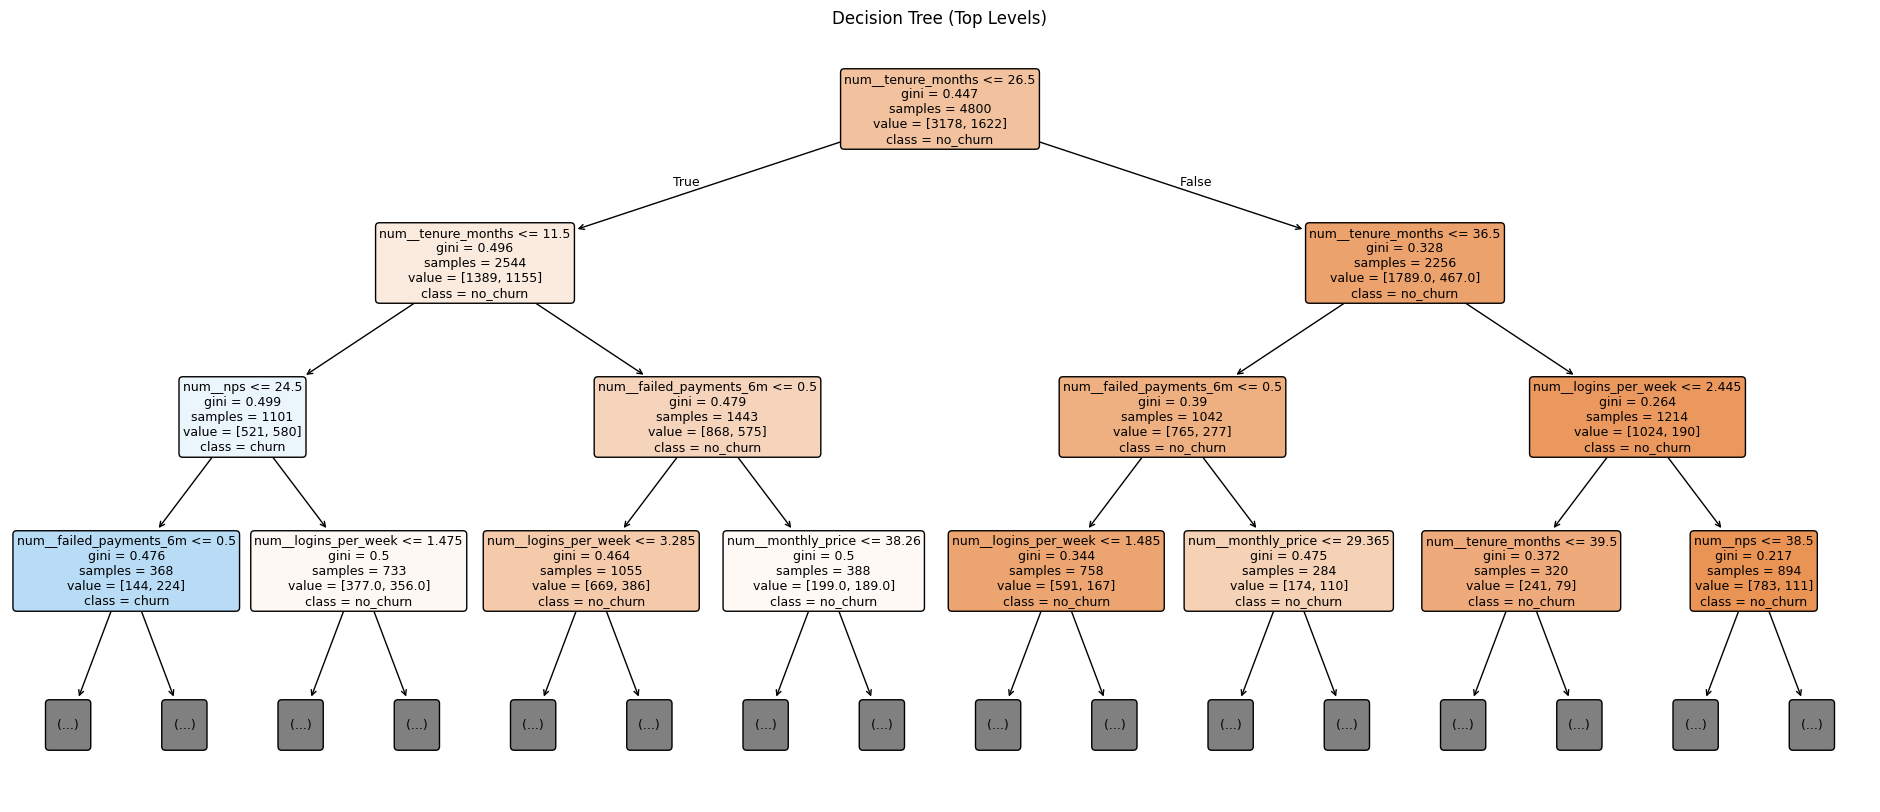

In [54]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["no_churn", "churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree (Top Levels)")
plt.show()

### 4.5.3. Text-based representation of the tree

In [55]:
from sklearn.tree import export_text

print(
    export_text(
        tree_model,
        feature_names=list(feature_names),
        max_depth=4
    )
)

|--- num__tenure_months <= 26.50
|   |--- num__tenure_months <= 11.50
|   |   |--- num__nps <= 24.50
|   |   |   |--- num__failed_payments_6m <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- num__failed_payments_6m >  0.50
|   |   |   |   |--- class: 1
|   |   |--- num__nps >  24.50
|   |   |   |--- num__logins_per_week <= 1.48
|   |   |   |   |--- class: 1
|   |   |   |--- num__logins_per_week >  1.48
|   |   |   |   |--- class: 0
|   |--- num__tenure_months >  11.50
|   |   |--- num__failed_payments_6m <= 0.50
|   |   |   |--- num__logins_per_week <= 3.28
|   |   |   |   |--- class: 0
|   |   |   |--- num__logins_per_week >  3.28
|   |   |   |   |--- class: 0
|   |   |--- num__failed_payments_6m >  0.50
|   |   |   |--- num__monthly_price <= 38.26
|   |   |   |   |--- class: 1
|   |   |   |--- num__monthly_price >  38.26
|   |   |   |   |--- class: 0
|--- num__tenure_months >  26.50
|   |--- num__tenure_months <= 36.50
|   |   |--- num__failed_payments_6m <= 0.50
|   |   |   |-

## 4.6. Summary

This analysis evaluated customer churn risk using both a probabilistic baseline model and an interpretable segmentation approach.

A logistic regression baseline was used to establish a stable reference for churn risk ranking, providing well-calibrated probability estimates and solid ranking performance. A decision tree model was then applied to expose the underlying structure of churn behavior and identify interpretable customer segments.

The analysis shows that customer tenure is the dominant driver of churn risk. Early-stage customers exhibit substantially higher churn probability, particularly when combined with low engagement, low satisfaction, or early payment issues. In contrast, long-tenured customers demonstrate strong retention stability across most behavioral and pricing conditions.

Overall, the results indicate that churn is driven primarily by early customer experience and engagement rather than static attributes. These findings support a retention strategy focused on early intervention, onboarding quality, and engagement monitoring, while treating long-tenured customers as a stable base for long-term value growth.